# Run Testbench and Export Response Time-Series

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [2]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"

case_path = andes.get_case(test_case_dir / "regcv1_testbench.xlsx")
STEP_TIME = 0.001 # 1 ms

In [3]:
ss = andes.load(case_path, setup=False)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 30 # Baruzzi et al ran simulation for 9s after disturbance

ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 0
ss.TDS.config.reset_tiny = 1

ss.TDS.run()

True

In [4]:
# the voltage and frequency being played back
andes_input_df = pd.read_excel(test_case_dir / "disturbance_profile.xlsx")
andes_input_df

,Time,Voltage,Frequency
0,0.000,0.990432,1.0
1,0.001,0.990432,1.0
2,0.002,0.990432,1.0
3,0.003,0.990432,1.0
4,0.004,0.990432,1.0
...,...,...,...
29956,29.956,0.989611,1.0
29957,29.957,0.989612,1.0
29958,29.958,0.989612,1.0
29959,29.959,0.989612,1.0


In [8]:
# get required time-series
pe_ts = ss.TDS.get_timeseries(ss.REGCV1.Pe).values[:, 0]
sim_time = ss.dae.ts.t
input_voltage_pu = np.interp(sim_time, andes_input_df.Time, andes_input_df.Voltage)
input_freq_pu = np.interp(sim_time, andes_input_df.Time, andes_input_df.Frequency)
omega = ss.TDS.get_timeseries(ss.REGCV1.dw).values[:, 0] # internal frequency
rocof = np.gradient(omega, sim_time)

# obtain bus angle and frequency
theta = np.unwrap(ss.TDS.get_timeseries(ss.REGCV1.a).values[:,0])
omega_bus = np.gradient(theta, sim_time) / (2 * np.pi) / 60


simulation_out = pd.DataFrame({
    "time": sim_time,
    "v_pu": input_voltage_pu,
    "f_pu": input_freq_pu,
    "omega_int":omega,
    "omega_bus":omega_bus,
    "rocof":rocof,
    "Pe_pu": pe_ts
})

simulation_out.set_index("time", inplace=True)

In [9]:
simulation_out

,v_pu,f_pu,omega_int,omega_bus,rocof,Pe_pu
time,,,,,,
0.0000,0.990432,1.0,0.000000e+00,0.000000e+00,0.000000,0.500000
0.0001,0.990432,1.0,0.000000e+00,-9.895059e-17,0.000000,0.500000
0.0009,0.990432,1.0,0.000000e+00,-7.539093e-17,0.000000,0.500000
0.0010,0.990432,1.0,0.000000e+00,0.000000e+00,0.000000,0.500000
0.0011,0.990432,1.0,0.000000e+00,5.536521e-17,0.000000,0.500000
...,...,...,...,...,...,...
29.9961,0.989612,1.0,9.558016e-07,9.509154e-07,-0.000009,0.500066
29.9971,0.989612,1.0,9.467804e-07,9.418321e-07,-0.000009,0.500067
29.9981,0.989612,1.0,9.377663e-07,9.327580e-07,-0.000009,0.500067


## Simulation Window

In [10]:
# standard deviation of RoCoF to select window
# try to stop before complete settling, as it would cause weird
# behavior in disturbance-based estimators

rocof_series = simulation_out["rocof"]

def rocof_std(a, b):
    """RoCoF magnitude over an interval (mHz/s)"""
    return np.std(rocof_series[(rocof_series.index >= a) & (rocof_series.index < b)]) * 60 * 1e3

for a, b in ((0, 1), (1, 2), (2, 3), (3, 4), (4,5), (5, 6), (6, 7), (7, 8)):
    std = rocof_std(a, b)
    print(f"  {a}-{b} s   {std:6.1f} mHz/s")

  0-1 s      0.1 mHz/s
  1-2 s    345.0 mHz/s
  2-3 s    127.6 mHz/s
  3-4 s    103.0 mHz/s
  4-5 s     99.2 mHz/s
  5-6 s     21.2 mHz/s
  6-7 s     15.2 mHz/s
  7-8 s     59.5 mHz/s


In [15]:
# select 1 (disturbance)-5s as the window
simulation_out_cut = simulation_out.loc[1:5]
#simulation_out_cut
simulation_out_cut.index-=1.0000 # reindex :>
simulation_out_cut

,v_pu,f_pu,omega_int,omega_bus,rocof,Pe_pu
time,,,,,,
1.110223e-15,0.984842,1.000000,1.843483e-07,-0.000010,0.000028,0.499714
1.000000e-04,0.984793,0.999997,1.871738e-07,-0.000010,0.000028,0.499711
9.000000e-04,0.984405,0.999972,2.108129e-07,-0.000011,0.000031,0.499688
1.000000e-03,0.984357,0.999969,2.138975e-07,-0.000011,0.000031,0.499685
1.100000e-03,0.984309,0.999965,2.170115e-07,-0.000011,0.000031,0.499682
...,...,...,...,...,...,...
3.998100e+00,0.983439,1.000362,3.100455e-04,0.000307,0.000506,0.487193
3.998900e+00,0.983436,1.000361,3.104486e-04,0.000307,0.000502,0.487216
3.999000e+00,0.983436,1.000361,3.104988e-04,0.000307,0.000502,0.487219


## Frequency-Divider Formula Attempt
$$\omega_{int} \approx \omega_{bus} + \frac{X_{eq}}{\omega_0}\frac{dP}{dt}$$

In [16]:
sim_time_cut = simulation_out_cut.index
W0 = 2 * np.pi * 60
X_EQ = 0.032 # Milano et al. calcluated from model parameters
dPdt = np.gradient(simulation_out_cut.Pe_pu.values, sim_time_cut)

# fdf definition
def fdf(x_eq, omega_bus, dpdt, w0):
    return omega_bus + x_eq * dpdt / w0

# calculate fdf using bus frequency to get estimated internal frequency
omega_fdf = fdf(X_EQ, simulation_out_cut.omega_bus.values, dPdt, W0)
omega_fdf

array([-1.25200043e-05, -1.25930155e-05, -1.30469889e-05, ...,
        3.09927639e-04,  3.09978943e-04,  3.10384708e-04], shape=(12000,))

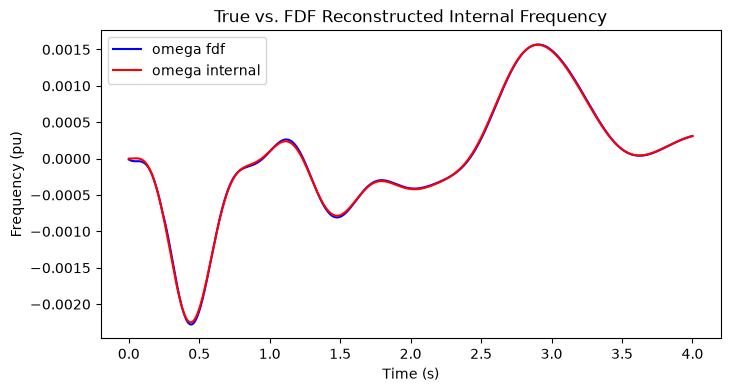

In [17]:
omega_er = omega_fdf - simulation_out_cut.omega_int

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim_time_cut, omega_fdf, color="blue", label="omega fdf")
ax.plot(sim_time_cut, simulation_out_cut.omega_int, color="red", label="omega internal")
ax.set_title("True vs. FDF Reconstructed Internal Frequency")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (pu)")
ax.legend()

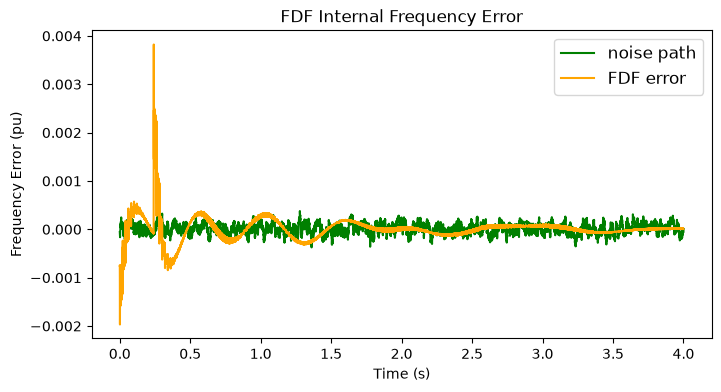

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
domega_fdf = np.gradient(omega_fdf, sim_time_cut)
domega_int = np.gradient(simulation_out_cut.omega_int.values, sim_time_cut)
domega_er = domega_fdf-domega_int

ax.plot(sim_time_cut, noise, color="green", label="noise path")
ax.plot(sim_time_cut, domega_er, color="orange", label="FDF error")
ax.set_title("FDF Internal Frequency Error")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency Error (pu)")
ax.legend(fontsize=12)

In [27]:
print("Standard deviation of errors as percentage of true value:")
print(f"Frequency Error = {100 * np.std(omega_er)/np.std(simulation_out_cut.omega_int.values):.3f}%")
print(f"RoCoF Error = {100 * np.std(domega_er)/np.std(domega_int):.3f}%")

Standard deviation of errors as percentage of true value:
Frequency Error = 1.862%
RoCoF Error = 7.119%


## Export

In [28]:
simulation_out_cut.to_csv(f"{project_dir}/out/simulation_data/simulation_timeseries.csv", index=True)